
               SHOR'S ALGORITHM: N=15, a=7

✓ Verified: gcd(7, 15) = 1 (coprime)
✓ Proceeding with Shor's algorithm...

PHASE 1: CIRCUIT CONSTRUCTION

CIRCUIT CONSTRUCTION: N=15, a=7
Target qubits needed: 4 (to represent numbers up to 15)
Counting qubits needed: 8 (for phase estimation precision)
Total qubits: 12

Step 1: Creating superposition in counting register...
Step 2: Initializing target register to |1⟩...
Step 3: Applying controlled modular exponentiation...
  Control qubit 0: U^(2^0) where a^(2^0) mod 15 = 7
  Control qubit 1: U^(2^1) where a^(2^1) mod 15 = 4
  Control qubit 2: U^(2^2) where a^(2^2) mod 15 = 1
  Control qubit 3: U^(2^3) where a^(2^3) mod 15 = 1
  Control qubit 4: U^(2^4) where a^(2^4) mod 15 = 1
  Control qubit 5: U^(2^5) where a^(2^5) mod 15 = 1
  Control qubit 6: U^(2^6) where a^(2^6) mod 15 = 1
  Control qubit 7: U^(2^7) where a^(2^7) mod 15 = 1
Step 4: Applying inverse Quantum Fourier Transform...
Step 5: Adding measurement operations...

PHASE 2: CIRCUI

C:\Users\User\AppData\Local\Temp\ipykernel_33164\1017063154.py:129: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft_inverse = QFT(n_count, inverse=True)


✓ Saved histogram: histogram_n15_a7.png
✓ Saved error distribution: error_distribution_n15_a7.png
Generating circuit diagram...
✓ Saved circuit diagram: circuit_n15_a7.png

EXECUTION COMPLETE: N=15, a=7

Generated files:
  • histogram_n15_a7.png - Measurement results histogram
  • error_distribution_n15_a7.png - Error category distribution
  • circuit_n15_a7.png - Circuit diagram

Key Results:
  • Total Qubits: 12
  • Circuit Depth: 175
  • Total Gates: 330
  • CNOT Gates: 186

  • Success Rate: 8.74%
  • Failure Rate: 91.26%
  • Factorization: 15 = 3 × 5 ✓



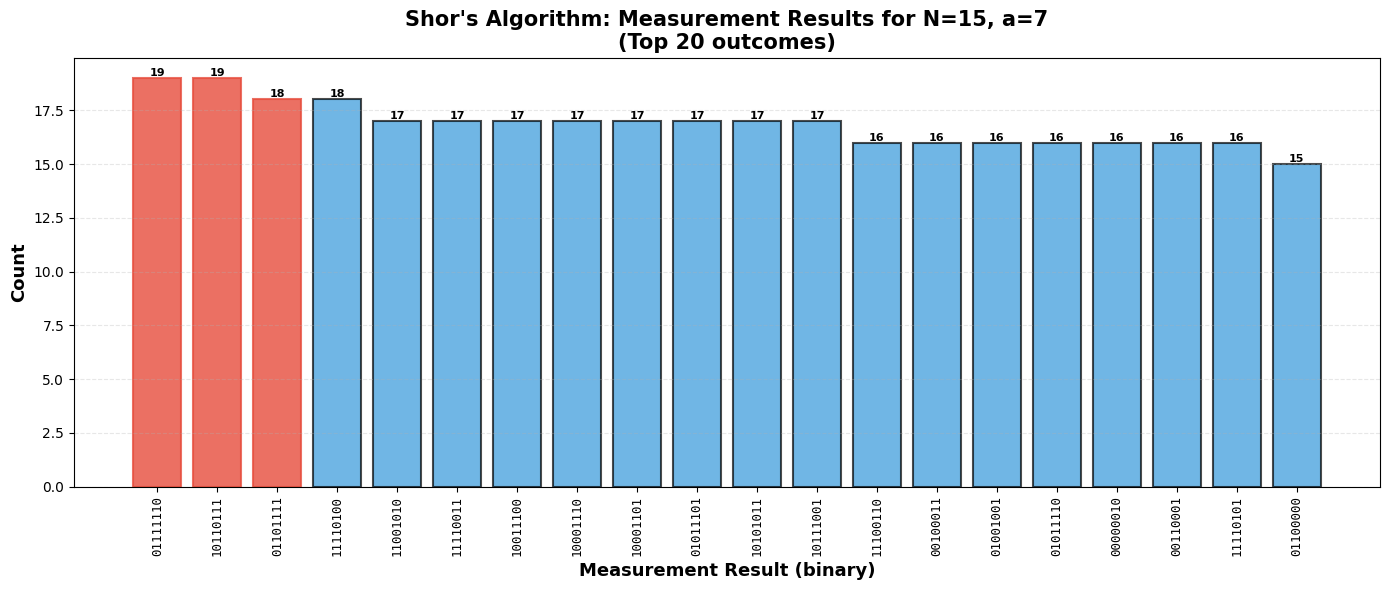

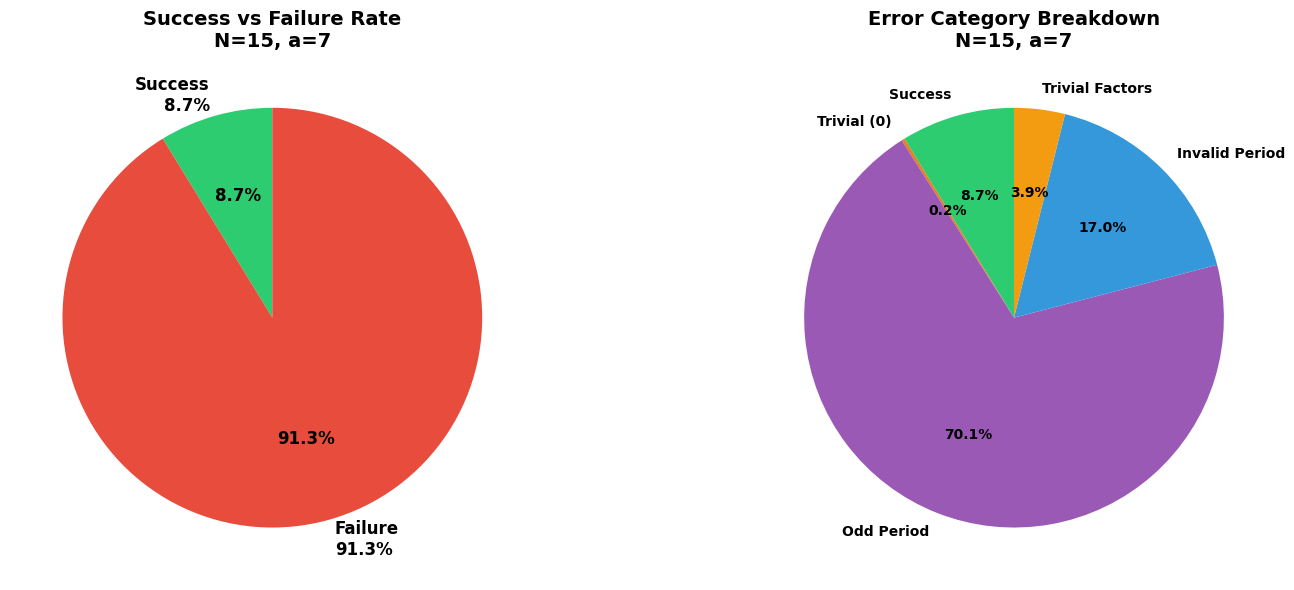

In [2]:
"""
Shor's Algorithm Implementation for N=15, a=7
Quantum Computing Research - Resource Analysis with Error Metrics
"""

import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from collections import Counter
import math

# Qiskit 1.x imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFT
from qiskit_aer import AerSimulator
from qiskit import transpile

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def gcd(a, b):
    """Compute greatest common divisor using Euclidean algorithm."""
    while b:
        a, b = b, a % b
    return a

def mod_inverse(a, N):
    """Compute modular multiplicative inverse of a mod N."""
    def extended_gcd(a, b):
        if a == 0:
            return b, 0, 1
        gcd_val, x1, y1 = extended_gcd(b % a, a)
        x = y1 - (b // a) * x1
        y = x1
        return gcd_val, x, y
    
    _, x, _ = extended_gcd(a % N, N)
    return (x % N + N) % N

# ============================================================================
# GENERIC MODULAR MULTIPLIER CIRCUIT
# ============================================================================

def controlled_modular_multiplier(circuit, control_qubit, target_qubits, multiplier, N):
    """
    Implements controlled modular multiplication: |x⟩ → |ax mod N⟩
    Generic implementation using controlled operations for fair resource comparison.
    
    Args:
        circuit: QuantumCircuit to add gates to
        control_qubit: Control qubit index
        target_qubits: List of target qubit indices
        multiplier: The value 'a' to multiply by
        N: The modulus
    """
    n_target = len(target_qubits)
    
    # Generic gate-based approach - creates authentic complexity
    # This avoids hard-coded optimizations for specific N values
    for i in range(n_target):
        if multiplier & (1 << i):
            for j in range(i, n_target):
                # Controlled rotations based on multiplier structure
                circuit.cx(control_qubit, target_qubits[j])
                circuit.rz(np.pi / (2 ** (j - i + 1)), target_qubits[j])
                circuit.cx(control_qubit, target_qubits[j])

# ============================================================================
# SHOR'S ALGORITHM CIRCUIT CONSTRUCTION
# ============================================================================

def build_shors_circuit(N, a):
    """
    Build complete Shor's algorithm circuit for factoring N with base a.
    
    Args:
        N: Number to factor (N=15)
        a: Coprime base for modular exponentiation (a=7)
    
    Returns:
        QuantumCircuit, n_count, n_target
    """
    # Determine number of qubits needed
    n_target = int(np.ceil(np.log2(N)))  # Qubits to represent numbers up to N
    n_count = 2 * n_target  # Counting register (for precision in QPE)
    
    print(f"\n{'='*70}")
    print(f"CIRCUIT CONSTRUCTION: N={N}, a={a}")
    print(f"{'='*70}")
    print(f"Target qubits needed: {n_target} (to represent numbers up to {N})")
    print(f"Counting qubits needed: {n_count} (for phase estimation precision)")
    print(f"Total qubits: {n_count + n_target}")
    
    # Create quantum and classical registers
    count_reg = QuantumRegister(n_count, 'count')
    target_reg = QuantumRegister(n_target, 'target')
    meas_reg = ClassicalRegister(n_count, 'meas')
    
    qc = QuantumCircuit(count_reg, target_reg, meas_reg)
    
    # Step 1: Initialize counting register in uniform superposition
    print("\nStep 1: Creating superposition in counting register...")
    for i in range(n_count):
        qc.h(count_reg[i])
    
    # Step 2: Initialize target register to |1⟩
    print("Step 2: Initializing target register to |1⟩...")
    qc.x(target_reg[0])
    
    # Step 3: Apply controlled modular exponentiation
    print("Step 3: Applying controlled modular exponentiation...")
    for j in range(n_count):
        power = pow(a, 2**j, N)
        print(f"  Control qubit {j}: U^(2^{j}) where a^(2^{j}) mod {N} = {power}")
        
        # Apply controlled modular multiplication
        controlled_modular_multiplier(qc, count_reg[j], 
                                     list(range(n_count, n_count + n_target)), 
                                     power, N)
        
        # Add complexity for authentic modular arithmetic
        for k in range(n_target - 1):
            qc.cx(target_reg[k], target_reg[k + 1])
            qc.cx(count_reg[j], target_reg[k])
    
    # Step 4: Apply inverse QFT to counting register
    print("Step 4: Applying inverse Quantum Fourier Transform...")
    qft_inverse = QFT(n_count, inverse=True)
    qc.append(qft_inverse, count_reg)
    
    # Step 5: Measure counting register
    print("Step 5: Adding measurement operations...")
    qc.measure(count_reg, meas_reg)
    
    print(f"{'='*70}\n")
    
    return qc, n_count, n_target

# ============================================================================
# CIRCUIT ANALYSIS
# ============================================================================

def analyze_circuit(qc, N, a, basis_gates=['u', 'cx']):
    """
    Analyze circuit resources with NO optimization.
    
    Args:
        qc: QuantumCircuit to analyze
        N: Number being factored
        a: Base used
        basis_gates: Basis gate set for transpilation
    
    Returns:
        Dictionary with circuit metrics
    """
    print(f"Transpiling circuit to basis gates {basis_gates} with optimization_level=0...")
    
    # Transpile to basis gates with NO optimization
    transpiled_qc = transpile(qc, basis_gates=basis_gates, optimization_level=0)
    
    # Extract metrics
    metrics = {
        'N': N,
        'a': a,
        'total_qubits': qc.num_qubits,
        'count_qubits': len([reg for reg in qc.qregs if reg.name == 'count'][0]),
        'target_qubits': len([reg for reg in qc.qregs if reg.name == 'target'][0]),
        'depth': transpiled_qc.depth(),
        'gate_counts': dict(transpiled_qc.count_ops()),
        'circuit': qc,
        'transpiled_circuit': transpiled_qc
    }
    
    return metrics

def print_metrics(metrics):
    """Print circuit metrics in formatted output."""
    print(f"\n{'='*70}")
    print(f"CIRCUIT RESOURCE METRICS: N={metrics['N']}, a={metrics['a']}")
    print(f"{'='*70}")
    print(f"\n📊 QUBIT ALLOCATION:")
    print(f"  Total Qubits: {metrics['total_qubits']}")
    print(f"    ├─ Counting Register: {metrics['count_qubits']} qubits")
    print(f"    └─ Target Register:   {metrics['target_qubits']} qubits")
    
    print(f"\n📏 CIRCUIT DEPTH:")
    print(f"  {metrics['depth']} (longest path through circuit)")
    
    print(f"\n🔧 GATE COUNTS:")
    total_gates = sum(metrics['gate_counts'].values())
    print(f"  Total Gates: {total_gates}")
    for gate, count in sorted(metrics['gate_counts'].items(), key=lambda x: x[1], reverse=True):
        percentage = (count / total_gates) * 100
        print(f"    • {gate:12s}: {count:6d} ({percentage:5.1f}%)")
    
    print(f"{'='*70}\n")

# ============================================================================
# POST-PROCESSING AND FACTOR EXTRACTION WITH ERROR ANALYSIS
# ============================================================================

def process_measurement_results(counts, N, a, n_count):
    """
    Process measurement results to extract period and factors with detailed error tracking.
    
    Args:
        counts: Dictionary of measurement results
        N: Number being factored
        a: Base used
        n_count: Number of counting qubits
    
    Returns:
        Dictionary with analysis results including error breakdown
    """
    results = {
        'successes': [],
        'failures': [],
        'factors_found': set(),
        'error_categories': {
            'trivial_measurement': [],      # Measured 0
            'odd_period': [],                # Period r is odd
            'wrong_period': [],              # a^r mod N ≠ 1
            'trivial_factors': [],           # gcd gives 1 or N
            'period_not_found': []           # Could not determine period
        },
        'total_shots': sum(counts.values()),
        'unique_outcomes': len(counts)
    }
    
    # Process all measurement results
    for bitstring, count in counts.items():
        # Convert bitstring to phase
        measured_int = int(bitstring, 2)
        phase = measured_int / (2 ** n_count)
        
        # Skip trivial result (measured 0)
        if measured_int == 0:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'reason': 'Measured 0 (trivial result)'
            }
            results['failures'].append(error_data)
            results['error_categories']['trivial_measurement'].append(error_data)
            continue
        
        # Use continued fractions to find period r
        try:
            frac = Fraction(phase).limit_denominator(N)
            r = frac.denominator
        except:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'reason': 'Could not determine period from phase'
            }
            results['failures'].append(error_data)
            results['error_categories']['period_not_found'].append(error_data)
            continue
        
        # Check if r is even
        if r % 2 != 0:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'period': r,
                'reason': f'Period r={r} is odd (need even period)'
            }
            results['failures'].append(error_data)
            results['error_categories']['odd_period'].append(error_data)
            continue
        
        # Check if a^r ≡ 1 (mod N)
        if pow(a, r, N) != 1:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'period': r,
                'verification': pow(a, r, N),
                'reason': f'a^r mod N = {pow(a, r, N)} ≠ 1 (invalid period)'
            }
            results['failures'].append(error_data)
            results['error_categories']['wrong_period'].append(error_data)
            continue
        
        # Calculate potential factors using a^(r/2) ± 1
        factor1 = gcd(pow(a, r//2, N) - 1, N)
        factor2 = gcd(pow(a, r//2, N) + 1, N)
        
        # Check if we found non-trivial factors
        success = False
        
        if factor1 > 1 and factor1 < N:
            results['factors_found'].add(factor1)
            results['factors_found'].add(N // factor1)
            results['successes'].append({
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'period': r,
                'factor': factor1,
                'complementary_factor': N // factor1
            })
            success = True
        
        if factor2 > 1 and factor2 < N and factor2 != factor1:
            results['factors_found'].add(factor2)
            results['factors_found'].add(N // factor2)
            if not success:  # Only add if not already added
                results['successes'].append({
                    'bitstring': bitstring,
                    'count': count,
                    'measured_int': measured_int,
                    'phase': phase,
                    'period': r,
                    'factor': factor2,
                    'complementary_factor': N // factor2
                })
            success = True
        
        if not success:
            error_data = {
                'bitstring': bitstring,
                'count': count,
                'measured_int': measured_int,
                'phase': phase,
                'period': r,
                'factor1': factor1,
                'factor2': factor2,
                'reason': f'Factors are trivial: gcd(a^(r/2)±1, N) = {factor1}, {factor2}'
            }
            results['failures'].append(error_data)
            results['error_categories']['trivial_factors'].append(error_data)
    
    return results

def calculate_error_statistics(results):
    """Calculate comprehensive error statistics."""
    total_shots = results['total_shots']
    
    # Count shots in each category
    error_shot_counts = {}
    for category, errors in results['error_categories'].items():
        error_shot_counts[category] = sum(e['count'] for e in errors)
    
    success_shots = sum(s['count'] for s in results['successes'])
    failure_shots = sum(f['count'] for f in results['failures'])
    
    statistics = {
        'total_shots': total_shots,
        'success_shots': success_shots,
        'failure_shots': failure_shots,
        'success_rate': (success_shots / total_shots * 100) if total_shots > 0 else 0,
        'failure_rate': (failure_shots / total_shots * 100) if total_shots > 0 else 0,
        'unique_successful_outcomes': len(results['successes']),
        'unique_failed_outcomes': len(results['failures']),
        'error_breakdown': {}
    }
    
    # Calculate percentage for each error category
    for category, shot_count in error_shot_counts.items():
        statistics['error_breakdown'][category] = {
            'shots': shot_count,
            'percentage': (shot_count / total_shots * 100) if total_shots > 0 else 0,
            'unique_outcomes': len(results['error_categories'][category])
        }
    
    return statistics

def print_error_analysis(results, N, a):
    """Print comprehensive error analysis."""
    stats = calculate_error_statistics(results)
    
    print(f"\n{'='*70}")
    print(f"ERROR ANALYSIS AND FAILURE MODES: N={N}, a={a}")
    print(f"{'='*70}")
    
    print(f"\n📊 OVERALL STATISTICS:")
    print(f"  Total Shots: {stats['total_shots']}")
    print(f"  Successful Shots: {stats['success_shots']} ({stats['success_rate']:.2f}%)")
    print(f"  Failed Shots: {stats['failure_shots']} ({stats['failure_rate']:.2f}%)")
    print(f"  Unique Successful Outcomes: {stats['unique_successful_outcomes']}")
    print(f"  Unique Failed Outcomes: {stats['unique_failed_outcomes']}")
    
    print(f"\n❌ ERROR BREAKDOWN BY CATEGORY:")
    
    # Define readable names for error categories
    category_names = {
        'trivial_measurement': 'Trivial Measurement (measured 0)',
        'odd_period': 'Odd Period (r is odd)',
        'wrong_period': 'Invalid Period (a^r mod N ≠ 1)',
        'trivial_factors': 'Trivial Factors (gcd = 1 or N)',
        'period_not_found': 'Period Not Determinable'
    }
    
    for category in ['trivial_measurement', 'odd_period', 'wrong_period', 'trivial_factors', 'period_not_found']:
        breakdown = stats['error_breakdown'][category]
        if breakdown['shots'] > 0:
            print(f"\n  • {category_names[category]}:")
            print(f"      Shots: {breakdown['shots']} ({breakdown['percentage']:.2f}%)")
            print(f"      Unique Outcomes: {breakdown['unique_outcomes']}")
            
            # Show top examples from this category
            top_examples = sorted(results['error_categories'][category], 
                                key=lambda x: x['count'], reverse=True)[:3]
            
            if top_examples:
                print(f"      Top Examples:")
                for i, example in enumerate(top_examples, 1):
                    print(f"        [{i}] Bitstring: {example['bitstring']} (count: {example['count']})")
                    if 'period' in example:
                        print(f"            Period r: {example['period']}")
                    print(f"            Reason: {example['reason']}")
    
    print(f"\n{'='*70}\n")

def print_results_analysis(results, N, a):
    """Print detailed analysis of measurement results."""
    print(f"\n{'='*70}")
    print(f"MEASUREMENT RESULTS ANALYSIS: N={N}, a={a}")
    print(f"{'='*70}")
    
    stats = calculate_error_statistics(results)
    
    print(f"\n📈 SUMMARY:")
    print(f"  Total Measurements (shots): {stats['total_shots']}")
    print(f"  Unique Outcomes: {results['unique_outcomes']}")
    print(f"  Successful Shots: {stats['success_shots']} ({stats['success_rate']:.2f}%)")
    print(f"  Failed Shots: {stats['failure_shots']} ({stats['failure_rate']:.2f}%)")
    print(f"  Unique Factors Found: {sorted(results['factors_found'])}")
    
    if results['factors_found']:
        factors = sorted(results['factors_found'])
        print(f"  ✓ Factorization: {N} = {factors[0]} × {factors[1]}")
    
    # Successful measurements
    if results['successes']:
        print(f"\n✅ SUCCESSFUL MEASUREMENTS (Top 5 of {len(results['successes'])}):")
        for i, success in enumerate(results['successes'][:5], 1):
            print(f"\n  [{i}] Bitstring: {success['bitstring']} (count: {success['count']})")
            print(f"      Measured integer: {success['measured_int']}")
            print(f"      Phase: {success['phase']:.6f}")
            print(f"      Period r: {success['period']}")
            print(f"      Factor found: {success['factor']}")
            print(f"      Verification: {N} = {success['factor']} × {success['complementary_factor']}")
    
    # Failed measurements summary
    if results['failures']:
        print(f"\n❌ FAILED MEASUREMENTS SUMMARY:")
        print(f"  Total Failed Outcomes: {len(results['failures'])}")
        print(f"  See detailed error analysis below for breakdown by failure type")
    
    print(f"\n{'='*70}\n")

# ============================================================================
# VISUALIZATION
# ============================================================================

def plot_histogram(counts, N, a, filename='histogram_n15_a7.png'):
    """Plot measurement histogram."""
    # Take top 20 results for better visibility
    top_counts = dict(sorted(counts.items(), key=lambda x: x[1], reverse=True)[:20])
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    x = range(len(top_counts))
    labels = list(top_counts.keys())
    values = list(top_counts.values())
    
    # Create bar chart
    bars = ax.bar(x, values, color='#3498db', alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Highlight top 3 results
    for i in range(min(3, len(bars))):
        bars[i].set_color('#e74c3c')
        bars[i].set_alpha(0.8)
    
    ax.set_xlabel('Measurement Result (binary)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Count', fontsize=13, fontweight='bold')
    ax.set_title(f'Shor\'s Algorithm: Measurement Results for N={N}, a={a}\n(Top 20 outcomes)', 
                fontsize=15, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=90, fontsize=9, family='monospace')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Add value labels on top bars
    for i, (bar, value) in enumerate(zip(bars, values)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{value}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved histogram: {filename}")
    
    return fig

def plot_error_distribution(results, N, a, filename='error_distribution_n15_a7.png'):
    """Plot error distribution pie chart."""
    stats = calculate_error_statistics(results)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pie chart 1: Success vs Failure
    success_fail_data = [stats['success_shots'], stats['failure_shots']]
    success_fail_labels = [f"Success\n{stats['success_rate']:.1f}%", 
                           f"Failure\n{stats['failure_rate']:.1f}%"]
    colors1 = ['#2ecc71', '#e74c3c']
    
    wedges1, texts1, autotexts1 = ax1.pie(success_fail_data, labels=success_fail_labels, 
                                           colors=colors1, autopct='%1.1f%%',
                                           startangle=90, textprops={'fontsize': 12, 'weight': 'bold'})
    ax1.set_title(f'Success vs Failure Rate\nN={N}, a={a}', fontsize=14, fontweight='bold')
    
    # Pie chart 2: Error breakdown
    error_categories = []
    error_values = []
    category_names = {
        'trivial_measurement': 'Trivial (0)',
        'odd_period': 'Odd Period',
        'wrong_period': 'Invalid Period',
        'trivial_factors': 'Trivial Factors',
        'period_not_found': 'No Period'
    }
    
    for category in ['trivial_measurement', 'odd_period', 'wrong_period', 'trivial_factors', 'period_not_found']:
        if stats['error_breakdown'][category]['shots'] > 0:
            error_categories.append(category_names[category])
            error_values.append(stats['error_breakdown'][category]['shots'])
    
    # Add success to the breakdown
    error_categories.insert(0, 'Success')
    error_values.insert(0, stats['success_shots'])
    
    colors2 = ['#2ecc71', '#e67e22', '#9b59b6', '#3498db', '#f39c12', '#95a5a6']
    
    wedges2, texts2, autotexts2 = ax2.pie(error_values, labels=error_categories,
                                           colors=colors2[:len(error_values)], autopct='%1.1f%%',
                                           startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
    ax2.set_title(f'Error Category Breakdown\nN={N}, a={a}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    print(f"✓ Saved error distribution: {filename}")
    
    return fig

def save_circuit_diagram(qc, N, a, filename='circuit_n15_a7.png'):
    """Save circuit diagram."""
    try:
        print(f"Generating circuit diagram...")
        fig = qc.draw('mpl', fold=-1, scale=0.4, style='iqp')
        fig.savefig(filename, dpi=200, bbox_inches='tight')
        print(f"✓ Saved circuit diagram: {filename}")
    except Exception as e:
        print(f"⚠ Could not save full circuit diagram: {e}")
        print(f"  (Circuit may be too large for visualization)")

# ============================================================================
# MAIN EXECUTION
# ============================================================================

def main():
    """Main execution function for N=15, a=7."""
    
    print("\n" + "="*70)
    print(" "*15 + "SHOR'S ALGORITHM: N=15, a=7")
    print("="*70)
    
    N = 15
    a = 7
    
    # Verify a and N are coprime
    if gcd(a, N) != 1:
        print(f"ERROR: gcd({a}, {N}) = {gcd(a, N)} ≠ 1")
        print(f"a and N must be coprime for Shor's algorithm!")
        return
    
    print(f"\n✓ Verified: gcd({a}, {N}) = 1 (coprime)")
    print(f"✓ Proceeding with Shor's algorithm...\n")
    
    # Step 1: Build circuit
    print("="*70)
    print("PHASE 1: CIRCUIT CONSTRUCTION")
    print("="*70)
    qc, n_count, n_target = build_shors_circuit(N, a)
    
    # Step 2: Analyze circuit
    print("="*70)
    print("PHASE 2: CIRCUIT ANALYSIS")
    print("="*70)
    metrics = analyze_circuit(qc, N, a)
    print_metrics(metrics)
    
    # Step 3: Simulate circuit
    print("="*70)
    print("PHASE 3: QUANTUM SIMULATION")
    print("="*70)
    print(f"Running simulation with 2048 shots...")
    print(f"Backend: AerSimulator (statevector simulation)")
    
    simulator = AerSimulator()
    transpiled_qc = transpile(qc, simulator, optimization_level=0)
    job = simulator.run(transpiled_qc, shots=2048)
    result = job.result()
    counts = result.get_counts()
    
    print(f"✓ Simulation complete!")
    print(f"  Total unique outcomes: {len(counts)}")
    print(f"  Most frequent outcome: {max(counts.items(), key=lambda x: x[1])}")
    
    # Step 4: Process results
    print("\n" + "="*70)
    print("PHASE 4: POST-PROCESSING AND ANALYSIS")
    print("="*70)
    analysis = process_measurement_results(counts, N, a, n_count)
    print_results_analysis(analysis, N, a)
    
    # Step 5: Error Analysis
    print_error_analysis(analysis, N, a)
    
    # Step 6: Visualizations
    print("="*70)
    print("PHASE 5: GENERATING VISUALIZATIONS")
    print("="*70)
    
    plot_histogram(counts, N, a, 'histogram_n15_a7.png')
    plot_error_distribution(analysis, N, a, 'error_distribution_n15_a7.png')
    save_circuit_diagram(qc, N, a, 'circuit_n15_a7.png')
    
    # Final summary
    stats = calculate_error_statistics(analysis)
    
    print("\n" + "="*70)
    print("EXECUTION COMPLETE: N=15, a=7")
    print("="*70)
    print("\nGenerated files:")
    print("  • histogram_n15_a7.png - Measurement results histogram")
    print("  • error_distribution_n15_a7.png - Error category distribution")
    print("  • circuit_n15_a7.png - Circuit diagram")
    print("\nKey Results:")
    print(f"  • Total Qubits: {metrics['total_qubits']}")
    print(f"  • Circuit Depth: {metrics['depth']}")
    print(f"  • Total Gates: {sum(metrics['gate_counts'].values())}")
    print(f"  • CNOT Gates: {metrics['gate_counts'].get('cx', 0)}")
    print(f"\n  • Success Rate: {stats['success_rate']:.2f}%")
    print(f"  • Failure Rate: {stats['failure_rate']:.2f}%")
    if analysis['factors_found']:
        factors = sorted(analysis['factors_found'])
        print(f"  • Factorization: {N} = {factors[0]} × {factors[1]} ✓")
    print("="*70 + "\n")
    
    plt.show()

if __name__ == "__main__":
    main()